**Libraries**

In [1]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths

from pathlib import Path

import numpy as np
from numpy.typing import NDArray
import pandas as pd

from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera
from bloodmoon.mask import codedmask, count
from bloodmoon.mask import variance, snratio

import darksun as ds
from darksun.types import Tag
from darksun.data import Log, DataLoader, CatalogueLoader
from darksun.benchmarking import dict2df
from darksun.utils import savefig_to

**Notebook's General Variables**

In [2]:
# save plot and images
SAVE_TO: str | Path = '/home/edoardo/Desktop/detector_smoothing/smoothing'
SAVE_THINGS: bool = False

ANALYSIS_CAM1A: bool = True
ANALYSIS_CAM1B: bool = True

**Mask and Data Specifics**

In [3]:
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

SKYFIELD: str = "GalacticCentre"
DATA_FITS: str = "galctr_rxte-sax_mask_050_1040x17_fmin0.0945_2-50keV_1ks"
#DATA_FITS: str = "galctr_rxte-sax_mask_050_1040x17_2-50keV_1ks"
#DATA_FITS: str = "galctr_rxte-sax_2-50keV_mask_050_1040x17_opaquemask_infdet"

ANALYSIS_ID: str = "singleCAM_iros_asymFitBounds"

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
DATASET: str = "reconstructed"

UPS_X: int = 2
UPS_Y: int = 1

VIGNETTING: bool = True
PSFY: bool = True

**Analysis Methods**

In [4]:
def extract_catalogue_angular_coords(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> pd.DataFrame:
    """
    Extracts the catalogue sources angular coords.
    """
    angles_x, angles_y = [], []
    for sourceID in log.log['ID']:
        anglex, angley = (
            ds.source_angular_coords(sourceID, catalogue, sdl, camera)
            if sourceID in catalogue.DLdata['ID']
            else (np.nan, np.nan)
        )
        angles_x.append(anglex)
        angles_y.append(angley)
        
    df = pd.DataFrame(
        {'ID': log.log['ID'], 'angle_x': angles_x, 'angle_y': angles_y}
    )
    return df


def get_angularcoords_residues(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> tuple[NDArray, NDArray]:
    """
    Computes the angular coords residues between the IROS
    sources and the catalogue sources in [arcmin].
    """
    angular_coords = extract_catalogue_angular_coords(log, catalogue, sdl, camera)
    angles_x, angles_y = map(
        np.array, (angular_coords['angle_x'], angular_coords['angle_y']),
    )
    res_x, res_y = (
        60 * np.abs(np.array(log.log['angle_x']) - angles_x),
        60 * np.abs(np.array(log.log['angle_y']) - angles_y),
    )
    return res_x, res_y


def extract_catalogue_fluences(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Extracts the catalogue sources fluences.
    """
    fluences = []
    for sourceID in log.log['ID']:
        fluence = (
            ds.source_fluence(sourceID, catalogue, sdl, camera, verbose)
            if sourceID in catalogue.DLdata['ID']
            else np.nan
        )
        fluences.append(fluence)
        
    df = pd.DataFrame(
        {'ID': log.log['ID'], 'fluence': fluences}
    )
    return df


def get_fluence_residues(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
    verbose: bool = True,
) -> NDArray:
    """
    Computes the percentage fluence residues between the IROS
    and the catalogue sources.
    """
    df = extract_catalogue_fluences(log, catalogue, sdl, camera, verbose)
    fluences = np.array(df['fluence'])
    res = np.array(log.log['fluence']) - fluences
    return res * 100 / fluences


def reconstruction_data(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Generates a Dataframe with output data from IROS.
    """
    ds.pixels_angular_resolution(camera)
    theta_res_x, theta_res_y = get_angularcoords_residues(
        log, catalogue, sdl, camera,
    )
    fluence_res = get_fluence_residues(
        log, catalogue, sdl, camera, verbose,
    )
    dmap = {
        log.name: {
            'ID': log.log['ID'],
            'Brightest': log.log['id_brightest'],
            'SNR': log.log['snr'],
            'DthetaX [arcmin]': theta_res_x,
            'DthetaY [arcmin]': theta_res_y,
            'Dfluence [%]': fluence_res,
        }
    }
    return dict2df(dmap)

**Load Mask and Data**

In [5]:
# load filepaths
mask_path, simul_data, save_path = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
    run_name=ANALYSIS_ID,
)

wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)

filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)

## USING BULK MASK with 1.5 mm cover ##


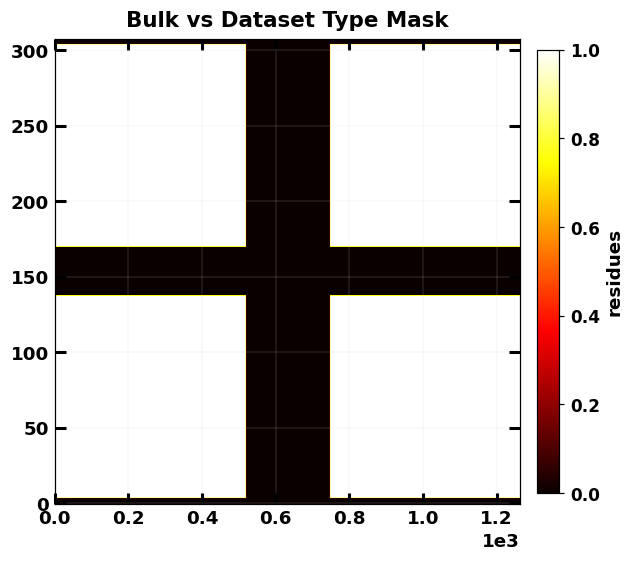

In [6]:
ds.image_plot(
    ds.map4image(
        img=wfm.bulk,
        title='Bulk vs Dataset Type Mask',
        cbarlabel='residues',
        img_kwargs={
            'aspect': wfm.shape_detector[1] / wfm.shape_detector[0],
            'cmap': 'hot',
        },
    )
)

In [7]:
# data from camera A
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET])
catalogueA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])
true_sky_camA, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1A_TEST_{ANALYSIS_ID}.fits")
res_sky_camA, _ = ds.load_sky(save_path + f"skyRES_IROS_CAM1A_TEST_{ANALYSIS_ID}.fits")

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


In [8]:
# data from camera B
sdlB = ds.get_data(filepaths[ID_CAMERA_B][DATASET])
catalogueB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])
true_sky_camB, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1B_TEST_{ANALYSIS_ID}.fits")
res_sky_camB, _ = ds.load_sky(save_path + f"skyRES_IROS_CAM1B_TEST_{ANALYSIS_ID}.fits")

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


In [9]:
log_camA, log_camB = ds.load_database(save_path + f"IROS_sources_database_TEST_{ANALYSIS_ID}.fits")

# Loading data...
# Loading completed!


In [10]:
# sources data + angular coords residues plot
reconstruction_data(
    log=log_camA,
    catalogue=catalogueA,
    sdl=sdlA,
    camera=wfm,
    verbose=False,
)


Pixel angular resolution at upscaling (x, y): (2, 1)
  - fine direction: 2.1163 arcmin
  - coarse direction: 8.4653 arcmin



CAM1A                                             \
                ID     Brightest         SNR DthetaX [arcmin]   
0            scox1         scox1  729.172476         0.142525   
1            gx5-1         gx5-1   71.011137         0.154856   
2          gx349+2       gx349+2   47.795181         0.210503   
3           gx17+2        gx17+2   43.072111         0.306855   
4            gx9+1         gx9+1   41.952856         0.228836   
5          gx340+0       gx340+0   30.191875         0.322033   
6           gx13+1        gx13+1   25.763638         0.304438   
7        x1820-303     x1820-303   23.584631         0.074906   
8      groj1655-40   groj1655-40   20.997231         0.406327   
9            gx3+1         gx3+1   20.567858         0.260837   
10           gx9+9         gx9+9   16.054535         0.084816   
11       x1705-440     x1705-440   15.492786         0.277574   
12           cirx1         cirx1   19.027682         0.364586   
13       x1735-444     x1735-444   12.248265         0.699354   
14         gx354-0       gx354-0    7.173585         0.189352   
15     grs1915+105   grs1915+105   12.864424         0.572981   
16  igrj17091-3624       gx349+2    5.119859         0.244691   
17    lemx-cam1aS1  lemx-cam1aS1    5.093989              NaN   
18       x1636-536     x1636-536    5.078048         0.504152   
19    lemx-cam1aS2  lemx-cam1aS2    5.497313              NaN   
20    lemx-cam1aS3  lemx-cam1aS3    5.105521              NaN   
21       x1630-472     x1630-472    5.016670         0.335804   
22    lemx-cam1aS4  lemx-cam1aS4    5.168425              NaN   

                                  
   DthetaY [arcmin] Dfluence [%]  
0          0.156866    -2.271925  
1          0.193760    -5.707743  
2          1.145307    -5.596698  
3          1.770586    -1.622144  
4          0.804574     3.610925  
5          8.679388    -4.578520  
6          1.698713     5.612586  
7         12.258710     1.865004  
8          7.290554     2.378620  
9          4.787790    -3.937152  
10         8.686960   -11.427090  
11        21.462822    37.548694  
12         4.471228    -8.996833  
13         1.815497    -1.092558  
14        20.988457    -8.430442  
15         9.013883    -9.706943  
16         1.488174   -19.722589  
17              NaN          NaN  
18        25.626670    -2.226909  
19              NaN          NaN  
20              NaN          NaN  
21        15.486806     9.281713  
22              NaN          NaN

In [11]:
# sources data + angular coords residues plot
reconstruction_data(
    log=log_camB,
    catalogue=catalogueB,
    sdl=sdlB,
    camera=wfm,
    verbose=False,
)


Pixel angular resolution at upscaling (x, y): (2, 1)
  - fine direction: 2.1163 arcmin
  - coarse direction: 8.4653 arcmin



CAM1B                                               \
                ID       Brightest         SNR DthetaX [arcmin]   
0            scox1           scox1  698.454179         0.141008   
1            gx5-1           gx5-1   77.366961         0.061961   
2          gx349+2         gx349+2   45.617458         0.825864   
3            gx9+1           gx9+1   44.329386         0.070500   
4           gx17+2          gx17+2   40.073295         0.162432   
5          gx340+0         gx340+0   32.508649         0.204392   
6           gx13+1          gx13+1   27.825085         0.028791   
7        x1820-303       x1820-303   22.484123         0.257109   
8            gx3+1           gx3+1   22.687981         0.146843   
9            gx9+9           gx9+9   21.154651         0.195173   
10     groj1655-40     groj1655-40   16.423385         0.955089   
11       x1735-444       x1735-444   14.994096         0.804473   
12           cirx1           cirx1   23.810026         0.474724   
13       x1705-440       x1705-440   13.777511         0.278251   
14         gx354-0         gx354-0    7.156063         0.774370   
15  igrj17091-3624  igrj17091-3624    6.251204         0.177167   
16       x1636-536       x1636-536    7.245960         0.033448   
17           serx1           serx1    8.503168         0.324953   
18       x1702-429       x1702-429    5.374775         0.666464   
19     grs1915+105     grs1915+105   13.849640         0.621002   
20    lemx-cam1bS1    lemx-cam1bS1    5.149725              NaN   
21    lemx-cam1bS2    lemx-cam1bS2    5.318463              NaN   
22    lemx-cam1bS3    lemx-cam1bS3    5.044796              NaN   

                                  
   DthetaY [arcmin] Dfluence [%]  
0          0.597364    -1.584565  
1          1.609065    -4.374287  
2          2.814783   -11.858063  
3          0.286576     2.324098  
4          2.626822   -10.547314  
5          3.390829    -0.167235  
6          8.431260    13.063172  
7          2.048308    -2.293238  
8         16.631238   -12.208994  
9          1.740687    -0.428633  
10         4.599984   -19.435683  
11        16.586198     7.093928  
12         2.143769     9.474540  
13         4.011329    -6.526622  
14         0.836724     1.304900  
15         7.557409    16.964592  
16        25.333983     7.771709  
17        27.155950    28.262092  
18        70.666929   108.848755  
19         2.731938    -8.393173  
20              NaN          NaN  
21              NaN          NaN  
22              NaN          NaN

In [12]:
assert False

AssertionError: 

**Analysis for LEM-X Camera A**

In [ ]:
assert ANALYSIS_CAM1A

In [ ]:
angular_coords = extract_catalogue_angular_coords(log_camA, wfm, catalogueA, sdlA)
cat_theta_x, cat_theta_y = map(
    np.array, (angular_coords['THETAX'], angular_coords['THETAY']),
)

theta_res_x, theta_res_y = get_angularcoords_residues(
    log=log_camA,
    catalogue=catalogueA,
    sdl=sdlA,
    camera=wfm,
)

tags_x = tuple(
    Tag(name, res, theta) for name, res, theta in zip(
        log_camA.log['ID'], theta_res_x, cat_theta_x,
    )
)
tags_y = tuple(
    Tag(name, res, theta) for name, res, theta in zip(
        log_camA.log['ID'], theta_res_y, cat_theta_y,
    )
)
dmapx = ds.map4plot(
    arrs=theta_res_x,
    title=f'{log_camA.name} X-Axis Angular Residues (abs values)',
    xlabel='$\\theta_{{x}}$ off-axis angle [deg]',
    ylabel='$\\Delta\\theta_{{x}}$ residues [arcmin]',
    x=cat_theta_x,
    style='scatter',
    color='OrangeRed',
    xlim=(-45, 45),
    yscale='log',
    tags=tags_x,
)
dmapy = ds.map4plot(
    arrs=theta_res_y,
    title=f'{log_camA.name} Y-Axis Angular Residues (abs values)',
    xlabel='$\\theta_{{y}}$ off-axis angle [deg]',
    ylabel='$\\Delta\\theta_{{y}}$ residues [arcmin]',
    x=cat_theta_y,
    style='scatter',
    color='OrangeRed',
    xlim=(-45, 45),
    yscale='log',
    tags=tags_y,
)

ds.plot(
    (dmapx, dmapy),
    ncols=2,
    save_to=(
        savefig_to(SAVE_TO, f'angularRes_{ID_CAMERA_A.upper()}')
        if SAVE_THINGS else None
    ),
)

In [ ]:
# sources profiles during IROS + residues heatmaps
cropy, cropx = (
    int(wfm.specs.slit_deltay * UPS_Y / wfm.specs.mask_deltay + 5),
    int(wfm.specs.slit_deltax * UPS_X / wfm.specs.mask_deltax + 5),
)
ds.reconstructed_sources_profiles(
    true_sky=true_sky_camA,
    log=log_camA,
    crp=(cropy, cropx),
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
    save_to=SAVE_TO if SAVE_THINGS else None,
)

In [ ]:
slit_fine, slit_coarse = ds.psf_extension(wfm)

ds.reconstruction_sources_heatmaps(
    true_sky=true_sky_camA,
    log=log_camA,
    crp=(slit_coarse + 5, slit_fine + 5),
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
    save_to=SAVE_TO if SAVE_THINGS else None,
)

In [ ]:
# sky significance distr. for true sky and at the last IROS iteration
detector_camA = count(wfm, sdlA.DLdata)[0]
varmap = variance(wfm, detector_camA)

ycut, xcut = UPS_Y * 30, UPS_X * 20
true_skysnr_camA = ds.unframe(snratio(true_sky_camA, varmap), ycut, xcut)
res_skysnr_camA = ds.unframe(snratio(res_sky_camA, varmap), ycut, xcut)

num_bins = 1000
density = True
hist_true_skysnr, bins = np.histogram(true_skysnr_camA, bins=num_bins, density=density)
hist_res_skysnr, _ = np.histogram(res_skysnr_camA, bins=bins, density=density)


x0, xN = -20, 50
bins_slice, hist_slice = ds.config_distr_limits(bins, x0, xN)

dmap1_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_res_skysnr[hist_slice]),
    title=f'Significance distr. {ID_CAMERA_A.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'IROS'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue'),
)
dmap2_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_res_skysnr[hist_slice]),
    title=f'Significance distr. (yscale log) {ID_CAMERA_A.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'IROS'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue'),
    yscale='log',
)
ds.plot(
    dmaps=(dmap1_snr, dmap2_snr),
    ncols=2,
    save_to=(
        savefig_to(SAVE_TO, f'snr_distr_{ID_CAMERA_A.upper()}')
        if SAVE_THINGS else None
    ),
)

**Analysis for LEM-X Camera B**

In [ ]:
assert ANALYSIS_CAM1B

In [ ]:
angular_coords = extract_catalogue_angular_coords(log_camB, wfm, catalogueB, sdlB)
cat_theta_x, cat_theta_y = map(
    np.array, (angular_coords['THETAX'], angular_coords['THETAY']),
)

theta_res_x, theta_res_y = get_angularcoords_residues(
    log=log_camB,
    catalogue=catalogueB,
    sdl=sdlB,
    camera=wfm,
)

tags_x = tuple(
    Tag(name, res, theta) for name, res, theta in zip(
        log_camB.log['ID'], theta_res_x, cat_theta_x,
    )
)
tags_y = tuple(
    Tag(name, res, theta) for name, res, theta in zip(
        log_camB.log['ID'], theta_res_y, cat_theta_y,
    )
)
dmapx = ds.map4plot(
    arrs=theta_res_x,
    title=f'{log_camB.name} X-Axis Angular Residues (abs values)',
    xlabel='$\\theta_{{x}}$ off-axis angle [deg]',
    ylabel='$\\Delta\\theta_{{x}}$ residues [arcmin]',
    x=cat_theta_x,
    style='scatter',
    color='OrangeRed',
    xlim=(-45, 45),
    yscale='log',
    tags=tags_x,
)
dmapy = ds.map4plot(
    arrs=theta_res_y,
    title=f'{log_camB.name} Y-Axis Angular Residues (abs values)',
    xlabel='$\\theta_{{y}}$ off-axis angle [deg]',
    ylabel='$\\Delta\\theta_{{y}}$ residues [arcmin]',
    x=cat_theta_y,
    style='scatter',
    color='OrangeRed',
    xlim=(-45, 45),
    yscale='log',
    tags=tags_y,
)

ds.plot(
    (dmapx, dmapy),
    ncols=2,
    save_to=(
        savefig_to(SAVE_TO, f'angularRes_{ID_CAMERA_B.upper()}')
        if SAVE_THINGS else None
    ),
)

In [ ]:
# sources profiles during IROS + residues heatmaps
cropy, cropx = (
    int(wfm.specs.slit_deltay * UPS_Y / wfm.specs.mask_deltay + 5),
    int(wfm.specs.slit_deltax * UPS_X / wfm.specs.mask_deltax + 5),
)
ds.reconstructed_sources_profiles(
    true_sky=true_sky_camB,
    log=log_camB,
    crp=(cropy, cropx),
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
    save_to=SAVE_TO if SAVE_THINGS else None,
)

In [ ]:
ds.reconstruction_sources_heatmaps(
    true_sky=true_sky_camB,
    log=log_camB,
    crp=(cropy, cropx),
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
    save_to=SAVE_TO if SAVE_THINGS else None,
)

In [ ]:
# sky significance distr. for true sky and at the last IROS iteration
detector_camB = count(wfm, sdlB.DLdata)[0]
varmap = variance(wfm, detector_camB)

ycut, xcut = UPS_Y * 30, UPS_X * 20
true_skysnr_camB = ds.unframe(snratio(true_sky_camA, varmap), ycut, xcut)
res_skysnr_camB = ds.unframe(snratio(res_sky_camA, varmap), ycut, xcut)

num_bins = 1000
density = True
hist_true_skysnr, bins = np.histogram(true_skysnr_camB, bins=num_bins, density=density)
hist_res_skysnr, _ = np.histogram(res_skysnr_camB, bins=bins, density=density)


x0, xN = None, None
bins_slice, hist_slice = ds.config_distr_limits(bins, x0, xN)

dmap1_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_res_skysnr[hist_slice]),
    title=f'Significance distr. {ID_CAMERA_B.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'IROS'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue'),
)
dmap2_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_res_skysnr[hist_slice]),
    title=f'Significance distr. (yscale log) {ID_CAMERA_B.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'IROS'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue'),
    yscale='log',
)
ds.plot(
    dmaps=(dmap1_snr, dmap2_snr),
    ncols=2,
    save_to=(
        savefig_to(SAVE_TO, f'snr_distr_{ID_CAMERA_B.upper()}')
        if SAVE_THINGS else None
    ),
)